# Используемые библиотеки

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import xgboost as xgb
import shap
import seaborn as sns
import matplotlib.pyplot as plt
import openpyxl
from xgboost import XGBRegressor
#чтобы вбить в память ctrl+enter
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.tree import plot_tree
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline


C:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Импортирование и препроцессинг данных

In [2]:
# загружаем файл иксель
df_kazan=pd.read_excel("Kazan.xlsx")
df_uljyanovsk=pd.read_excel("Uljanovsk.xlsx")

In [3]:
# соединяем два фрейма df_kazan и df_uljyanovsk по 5 общим стобцам
columns = ['Residual pipeline wall thickness, %',
          'Previous incidents on the pipeline section, K2',
          'Soil corrosion activity, К3',
          'Flooding (traces of flooding) of the channel, K4',
          'Intersections with communications, K5',
          'Practical Ki-values']
df_common = pd.concat([df_kazan[columns], df_uljyanovsk[columns]]).reset_index(drop=True)
df_common.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Residual pipeline wall thickness, %               111 non-null    float64
 1   Previous incidents on the pipeline section, K2    111 non-null    object 
 2   Soil corrosion activity, К3                       111 non-null    object 
 3   Flooding (traces of flooding) of the channel, K4  111 non-null    object 
 4   Intersections with communications, K5             111 non-null    object 
 5   Practical Ki-values                               111 non-null    float64
dtypes: float64(2), object(4)
memory usage: 5.3+ KB


In [4]:
# переименовываем названия столбцов для упрощения работы с ними

df_common=df_common.rename(columns={'Residual pipeline wall thickness, %': 'K1',
                                    'Previous incidents on the pipeline section, K2':'K2',
                                    'Soil corrosion activity, К3':'K3',
                                    'Flooding (traces of flooding) of the channel, K4':'K4',
                                    'Intersections with communications, K5':'K5',
                                    'Practical Ki-values':'Ki'})
df_common

,K1,K2,K3,K4,K5,Ki
0,34.285714,no,low,no,no,1.198338
1,17.500000,no,low,yes,no,1.039036
2,20.000000,yes,middle,yes,yes,1.117360
3,52.500000,no,low,no,no,1.291050
4,17.500000,yes,middle,yes,yes,1.244783
...,...,...,...,...,...,...
106,64.285714,yes,low,yes,no,0.983205
107,44.444444,yes,high,yes,yes,0.887565
108,30.000000,yes,low,no,no,1.423080
109,50.000000,yes,high,no,no,1.158972


In [5]:
# переопределяем тип данных для фрейма df_common
df_common.K2=df_common.K2.astype('category').cat.codes
df_common.K3=df_common.K3.astype('category').cat.codes
df_common.K4=df_common.K4.astype('category').cat.codes
df_common.K5=df_common.K5.astype('category').cat.codes

In [6]:
df_common.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   K1      111 non-null    float64
 1   K2      111 non-null    int8   
 2   K3      111 non-null    int8   
 3   K4      111 non-null    int8   
 4   K5      111 non-null    int8   
 5   Ki      111 non-null    float64
dtypes: float64(2), int8(4)
memory usage: 2.3 KB


# Предварительный анализ данных

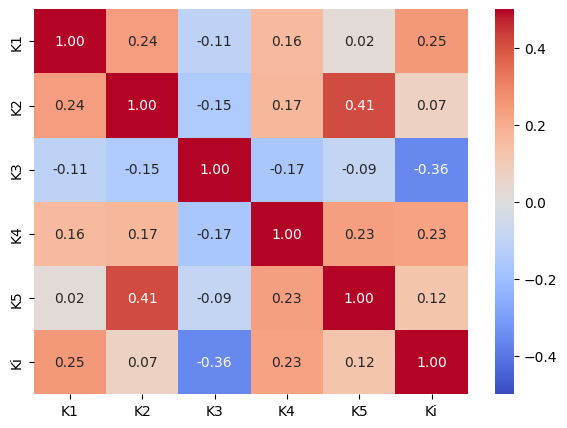

In [7]:
#рисуем матрицу корреляции Пирсона

plt.figure(figsize=(7,5))
sns.heatmap(df_common.corr(), annot=True, fmt=".2f", cmap='coolwarm',cbar=True, vmin=-0.5, vmax=0.5)
plt.show()

Text(0.5, 1.0, 'Distribution of actual Ki-vaiues in the population of data')

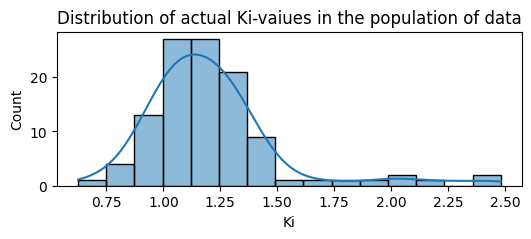

In [8]:
#проверяем распределение величины Кi

plt.figure(figsize=(6, 2))
sns.histplot(data=df_common, x = 'Ki', bins = 15, kde=True)
plt.title('Distribution of actual Ki-vaiues in the population of data')

In [9]:
df_common = df_common.sort_values(by = 'Ki', ascending=True)
df_common.reset_index(drop=True, inplace=True)
df_common = df_common.iloc[8:85]

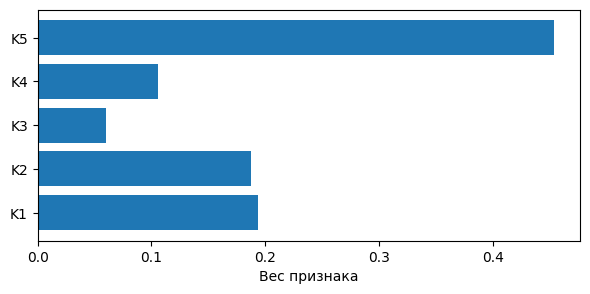

In [10]:
#разделяем генеральную совокупность на тренировочную и тестовую выборки 
X = df_common.drop(columns='Ki').copy()
y = df_common.Ki.copy()

# Standardization of input feature general set 
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.2, random_state=30)

'''X_train, X_test, y_train, y_test= train_test_split(df_common.drop('Ki',axis=1), 
                                                   df_common.Ki, 
                                                   test_size=0.2, 
                                                   random_state=30)'''
selector= XGBRegressor(random_state=42)
selector.fit(X_train, y_train)
plt.figure(figsize=(7, 3))
plt.barh(range(X_train.shape[1]), selector.feature_importances_, align='center')
plt.yticks(range(X_train.shape[1]), X_train.columns)
plt.xlabel('Вес признака')
plt.show()

In [11]:
# формируем отчетность по проекту
predictions = {}
errors = pd.DataFrame()
MSE, MAE, MAPE = {}, {}, {}

# Keras

<function matplotlib.pyplot.show(close=None, block=None)>

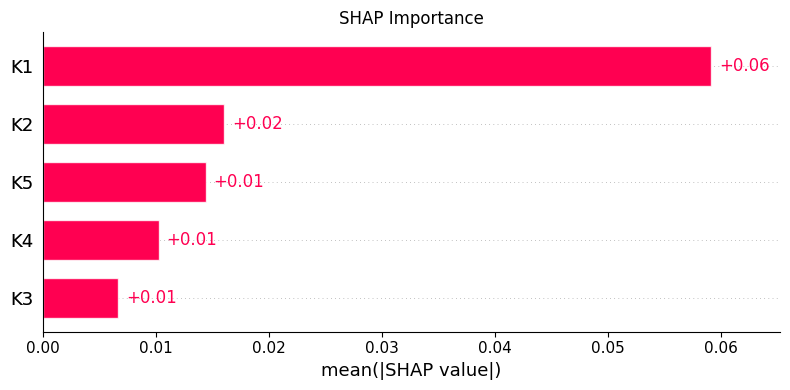

In [12]:
selector = xgb.XGBRegressor(random_state=5)
selector.fit(X_std, y)

explainer = shap.Explainer(selector)
shap_importances = explainer(X_std)

shap.plots.bar(shap_importances, show=False)

plt.title('SHAP Importance')
plt.tight_layout()
#plt.savefig('pictures/SHAP_Importance.png', dpi = 300, transparent = True)
plt.show

In [13]:
# генерируем нейронную сеть MLP с двумя скрытыми слоем
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(5,)),  # Явное указание входной формы
    tf.keras.layers.Dense(32, activation='softmax'),
    tf.keras.layers.Dense(32, activation='softmax'),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9), 
              loss='mean_squared_error', 
              metrics=['mae', 'mape'])

history = model.fit(X_train, y_train, epochs=500, batch_size=11, validation_data=(X_test, y_test), verbose = 0)
#model.predict(X_train)

In [14]:
# loss (MSE & MAE) history
loss = history.history['loss']
val_loss = history.history['val_loss']
mae = history.history['mae']
val_mae = history.history['val_mae']
epochs = range(1, len(loss) + 1)

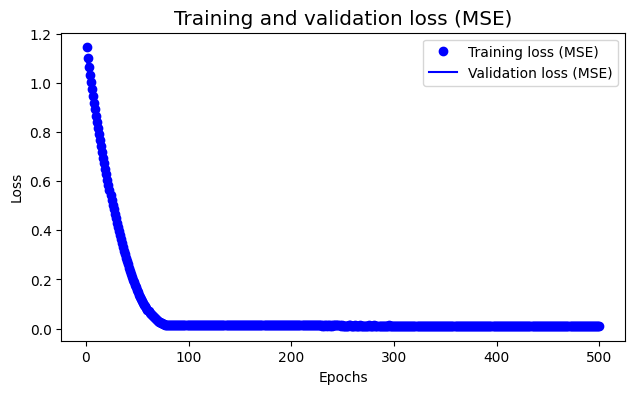

In [15]:
# MSE chart
plt.figure(figsize=(16, 4))
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Training loss (MSE)')
plt.plot(epochs, val_loss, 'b', label='Validation loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.size'] = 12
#plt.savefig('pictures/loss_MSE.png', dpi = 300, transparent = True)
plt.title('Training and validation loss (MSE)')
plt.show()

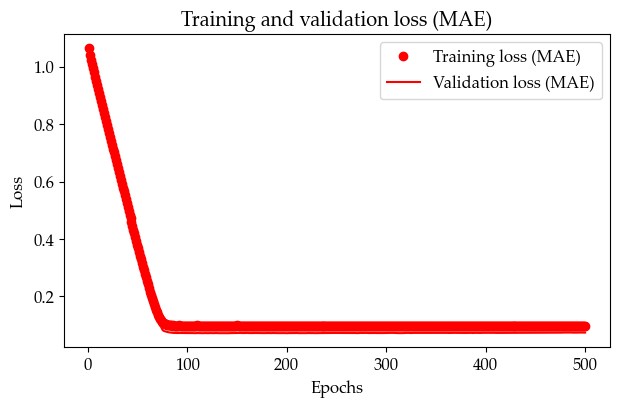

In [16]:
# MAE chart
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 2)
plt.plot(epochs, mae, 'ro', label='Training loss (MAE)')
plt.plot(epochs, val_mae, 'r', label='Validation loss (MAE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.size'] = 12
#plt.savefig('pictures/loss_MAE.png', dpi = 300, transparent = True)
plt.title('Training and validation loss (MAE)')
plt.show()

In [17]:
# Evaluate model performance on test data
test_loss, test_mae, test_mape = model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.0075 - mae: 0.0735 - mape: 6.6695


In [18]:
# error in test set
y_pred = model.predict(X_test)
y_pred = np.asarray(list(i[0] for i in y_pred))
predictions['MLP'] = y_pred
errors['MLP'] = (y_pred - y_test)/y_test
MSE['MLP'], MAE['MLP'], MAPE['MLP'] = test_loss, test_mae, test_mape/100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


In [19]:
print(f"MAE: {MAE}")
print(f"MSE: {MSE}")
print(f"MAPE: {MAPE}")

MAE: {'MLP': 0.07353819906711578}
MSE: {'MLP': 0.007543583400547504}
MAPE: {'MLP': 0.06669489860534668}


# XGBoost

In [20]:
%%time

# строим сетку и ищем лучшие гиперпараметры модели
XGB_grid = GridSearchCV(estimator=XGBRegressor(device='cpu', subsample=0.5), # строим схему для XGBoost-Регрессора
                        param_grid={"max_depth": range(2, 8), # глубина дерева
                                   'learning_rate': [0.01, 0.1, 0.2], # сокращение без признака
                                   'n_estimators':[30, 50, 100], # количество деревьев
                                   'gamma': [ 0, 0.1, 1, 10],
                                   'min_child_weight': [ 0, 0.1, 1, 10]},
                        scoring='neg_mean_absolute_percentage_error',
                        verbose=0,
                        cv=5)

XGB_grid.fit(X_train, y_train)
print('Best XGBRegressor-params', XGB_grid.best_params_)
                        

Best XGBRegressor-params {'gamma': 0, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 0, 'n_estimators': 100}
CPU times: total: 14min 47s
Wall time: 1min 56s


In [21]:
# используем полученные гиперпараметры для прогноза

XGB_best = XGB_grid.best_estimator_
y_pred  = XGB_best.predict(X_test)
y_pred

array([1.0964273, 1.0989891, 1.1086446, 1.1086446, 1.0671593, 1.0964273,
       1.0681052, 1.174126 , 1.1049361, 1.1171443, 1.1129841, 1.1112057,
       1.1359819, 1.1483955, 1.1055124, 1.174126 ], dtype=float32)

In [22]:
# сравним  прогнозные y_pred значения с фактическими y_test
mae_xgboost = float(mean_absolute_error(y_pred, y_test))
mape_xgboost = float(mean_absolute_percentage_error(y_pred, y_test))
mse_xgboost = float(mean_squared_error(y_pred, y_test))

print(f'MAE: {mae_xgboost}',
     f'MAPE: {mape_xgboost}',
     f'MSE: {mse_xgboost}', sep='\n')   

MAE: 0.06884513499166946
MAPE: 0.061615638927856854
MSE: 0.0062181892876082175


In [23]:
# error in test set
predictions['XGBoost'] = y_pred
errors['XGBoost'] = (y_pred - y_test)/y_test
MSE['XGBoost'], MAE['XGBoost'], MAPE['XGBoost'] = mse_xgboost, mae_xgboost, mape_xgboost

In [24]:
print(f"MAE: {MAE}")
print(f"MSE: {MSE}")
print(f"MAPE: {MAPE}")

MAE: {'MLP': 0.07353819906711578, 'XGBoost': 0.06884513499166946}
MSE: {'MLP': 0.007543583400547504, 'XGBoost': 0.0062181892876082175}
MAPE: {'MLP': 0.06669489860534668, 'XGBoost': 0.061615638927856854}


# SVM

In [25]:
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],  # Kernel coefficient
    'epsilon': [0.01, 0.1, 0.2, 0.5, 1],  # Margin parameter
    'kernel': ['rbf', 
               'linear', 
               #'poly', 
               'sigmoid']  # kernel type
}

svr = SVR()


grid_search = GridSearchCV(estimator=svr, 
                           param_grid=param_grid, 
                           cv=5, 
                           scoring='neg_mean_squared_error', 
                           verbose=2, n_jobs=-1)

In [26]:
%%time

# fit model
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 300 candidates, totalling 1500 fits
CPU times: total: 1.36 s
Wall time: 8.26 s


GridSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'epsilon': [0.01, 0.1, 0.2, 0.5, 1],
                         'gamma': ['scale', 'auto', 0.01, 0.1, 1],
                         'kernel': ['rbf', 'linear', 'sigmoid']},
             scoring='neg_mean_squared_error', verbose=2)

In [27]:
print("Best SVM-params:", grid_search.best_params_)

Best SVM-params: {'C': 0.1, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'sigmoid'}


In [28]:
best_svr = grid_search.best_estimator_
y_pred = best_svr.predict(X_test)
predictions['SVM'] = y_pred
errors['SVM'] = (y_pred - y_test)/y_test

In [29]:
mse_SVM = float(mean_squared_error(y_test, y_pred))
mae_SVM = float(mean_absolute_error(y_test, y_pred))
mape_SVM = float(mean_absolute_percentage_error(y_test, y_pred))

print(f"Mean Squared Error: {mse_SVM}")
print(f"Mean Absolute Error: {mae_SVM}")
print(f"Mean Absolute Percentage Error: {mape_SVM}")

Mean Squared Error: 0.008234841827501508
Mean Absolute Error: 0.07490458883515354
Mean Absolute Percentage Error: 0.06831286547855078


In [30]:
# error in test set
predictions['SVM'] = y_pred
errors['SVM'] = (y_pred - y_test)/y_test
MSE['SVM'], MAE['SVM'], MAPE['SVM'] = mse_SVM, mae_SVM, mape_SVM

In [31]:
print(f"MAE: {MAE}")
print(f"MSE: {MSE}")
print(f"MAPE: {MAPE}")

MAE: {'MLP': 0.07353819906711578, 'XGBoost': 0.06884513499166946, 'SVM': 0.07490458883515354}
MSE: {'MLP': 0.007543583400547504, 'XGBoost': 0.0062181892876082175, 'SVM': 0.008234841827501508}
MAPE: {'MLP': 0.06669489860534668, 'XGBoost': 0.061615638927856854, 'SVM': 0.06831286547855078}


# Random Forest

In [32]:
# Pipeline for Random Forest
rf_pipeline = Pipeline([
    ('regressor', RandomForestRegressor())
])

# Parameters GridSearchCV for Random Forest
rf_params = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_features': [0.3, 'sqrt', 'log2'],
    'regressor__max_depth': [5, 10, 15]
}

# Creation and execution GridSearchCV for Random Forest
rf_grid = GridSearchCV(rf_pipeline, rf_params, cv=5, scoring='neg_mean_absolute_percentage_error')
rf_grid.fit(X_train, y_train)

print("Best RF-params:", rf_grid.best_params_)

Best RF-params: {'regressor__max_depth': 15, 'regressor__max_features': 'sqrt', 'regressor__n_estimators': 100}


In [33]:
best_rf = rf_grid.best_estimator_
best_r_rf = rf_grid.best_estimator_.named_steps['regressor']
y_pred = best_rf.predict(X_test)
predictions['RF'] = y_pred
errors['RF'] = (y_pred - y_test)/y_test

In [34]:
mse_rf = float(mean_squared_error(y_test, y_pred))
mae_rf = float(mean_absolute_error(y_test, y_pred))
mape_rf = float(mean_absolute_percentage_error(y_test, y_pred))

print(f"Mean Squared Error: {mse_rf}")
print(f"Mean Absolute Error: {mae_rf}")
print(f"Mean Absolute Percentage Error: {mape_rf}")

Mean Squared Error: 0.008068111744306557
Mean Absolute Error: 0.07584923966432473
Mean Absolute Percentage Error: 0.06823431027347206


In [35]:
MSE['RF'], MAE['RF'], MAPE['RF'] = mse_rf, mae_rf, mape_rf

In [36]:
print(f"MAE: {MAE}")
print(f"MSE: {MSE}")
print(f"MAPE: {MAPE}")

MAE: {'MLP': 0.07353819906711578, 'XGBoost': 0.06884513499166946, 'SVM': 0.07490458883515354, 'RF': 0.07584923966432473}
MSE: {'MLP': 0.007543583400547504, 'XGBoost': 0.0062181892876082175, 'SVM': 0.008234841827501508, 'RF': 0.008068111744306557}
MAPE: {'MLP': 0.06669489860534668, 'XGBoost': 0.061615638927856854, 'SVM': 0.06831286547855078, 'RF': 0.06823431027347206}


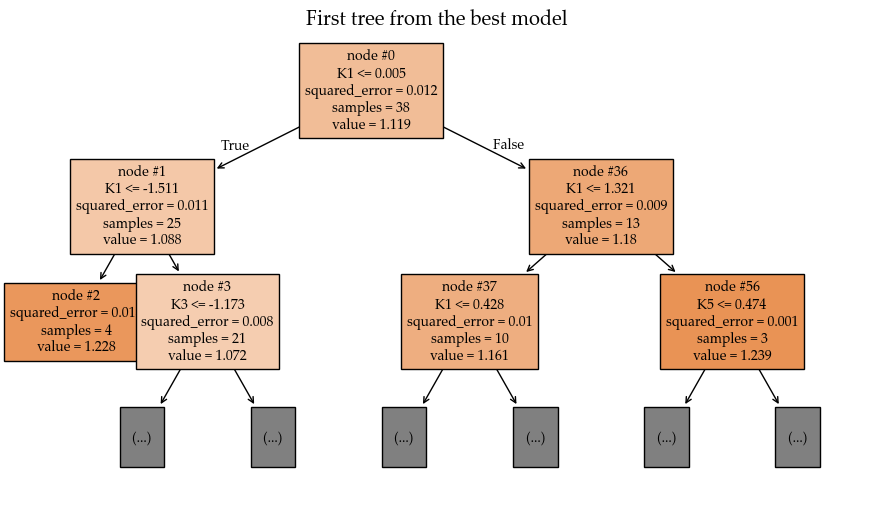

In [37]:
# Drawing the first tree from the best model
fig, ax = plt.subplots(figsize=(11, 6))
plot_tree(best_r_rf.estimators_[0], 
          filled=True, 
          feature_names=X_train.columns.tolist(), 
          ax=ax, 
          fontsize=10, 
          max_depth=2, 
          node_ids=True)

plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.size'] = 12
#plt.savefig('pictures/tree.png', dpi = 300, transparent = True)
plt.title('First tree from the best model')

plt.show()

Error indicator with a full set input features


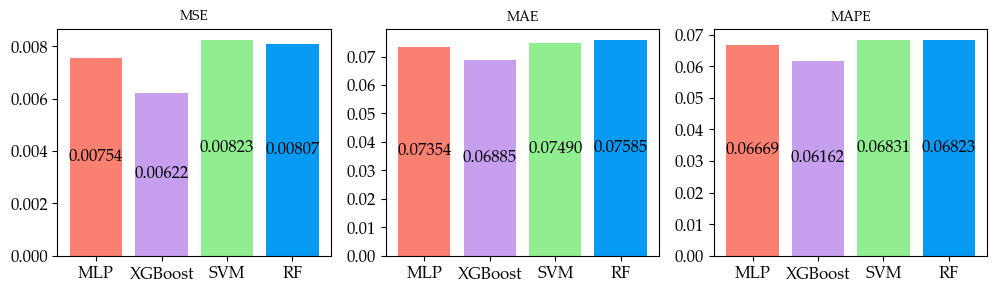

In [38]:
models = list(MSE)
plt.figure(figsize=(12, 10))

for index, score in enumerate(['MSE', 'MAE', 'MAPE']):
    scores = [MSE, MAE, MAPE]
    
    plt.subplot(3, 3, index + 1)
    bars =plt.bar(models, 
            scores[index].values(), 
            color=['#FA8072', '#C79FEF', '#90EE90', '#069AF3'],
            align='center')
    
    plt.bar_label(bars, label_type='center', fmt='%.5f')
    plt.title(score, fontsize = 10)
    
plt.tight_layout
plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.size'] = 10
plt.savefig('pictures/scores.png', dpi = 300, transparent = True)
print('Error indicator with a full set input features')

plt.show()

In [39]:
errors.reset_index(drop=True, inplace=True)
errors.reset_index(drop=False, inplace=True)
errors.head()

,index,MLP,XGBoost,SVM,RF
0,0,-0.052220,-0.064255,-0.040328,-0.080297
1,1,0.061327,0.046082,0.074091,0.001218
2,2,0.006403,-0.019466,0.002368,-0.039767
3,3,0.003014,-0.021604,0.000688,-0.070202
4,4,0.171514,0.120831,0.184098,0.096771


In [40]:
df_errors1 = errors[['index', 'MLP']]
df_errors1.insert(loc=2,column='score', value='MLP')
df_errors1 = df_errors1.rename(columns={'MLP':'error'})

df_errors2 = errors[['index', 'SVM']]
df_errors2.insert(loc=2,column='score', value='SVM')
df_errors2 = df_errors2.rename(columns={'SVM':'error'})

df_errors3 = errors[['index', 'XGBoost']]
df_errors3.insert(loc=2,column='score', value='XGBoost')
df_errors3 = df_errors3.rename(columns={'XGBoost':'error'})

df_errors4 = errors[['index', 'RF']]
df_errors4.insert(loc=2,column='score', value='RF')
df_errors4 = df_errors4.rename(columns={'RF':'error'})

df_errors = pd.concat([df_errors1, df_errors2, df_errors3, df_errors4], axis=0)
df_errors = df_errors.rename(columns={'index':'Incident number', 
                                      'error':'Relative error',
                                      'score': 'Model'})
df_errors.head(4)

,Incident number,Relative error,Model
0,0,-0.052220,MLP
1,1,0.061327,MLP
2,2,0.006403,MLP
3,3,0.003014,MLP


<Figure size 500x1200 with 0 Axes>

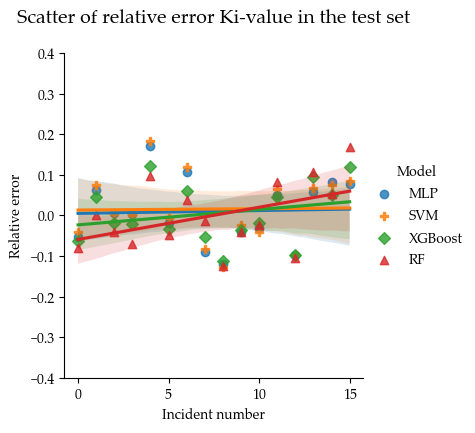

In [41]:
# Relative error on validation data
plt.figure(figsize=(5, 12))

sns.lmplot(x='Incident number', 
           y='Relative error', 
           data=df_errors,
           fit_reg=True, 
           hue='Model', 
           legend=True,
           markers=["o", "P", "D", "^"],
           scatter=True, 
           height=4)

#plt.legend(loc='best')
plt.ylim(-0.4, 0.4)
plt.rcParams['font.size'] = 14
plt.savefig('pictures/relative_error.png', dpi = 300, transparent = True)
plt.title('Scatter of relative error Ki-value in the test set\n', {'fontsize': 14})

plt.show()